<a href="https://colab.research.google.com/github/Eclipse-17/prediksi-sewa-sepeda-harian-berdasarkana-cuaca/blob/app/Perbandingan%20Kinerja%20Regression%20Tree%2C%20Random%20Forest%20Regressor%2C%20dan%20XGBoost%20dalam%20Prediksi%20Permintaan%20Sepeda%20Sewa%20Harian%20Berdasarkan%20Cuaca%20dan%20Waktu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd

# Muat dataset dari file yang disediakan
df = pd.read_csv('/content/day (1).csv')

print('Dataset berhasil dimuat! Berikut 5 baris pertamanya:')
display(df.head())

Dataset berhasil dimuat! Berikut 5 baris pertamanya:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## 1. Data Understanding (Pemahaman Data)

Langkah pertama adalah memahami struktur dan konten dari dataset yang telah kita muat. Kita akan melihat informasi dasar seperti tipe data, jumlah nilai non-null, dan statistik deskriptif.

In [59]:
print('\nInformasi Dataset (Tipe Data dan Jumlah Non-Null):')
display(df.info())


Informasi Dataset (Tipe Data dan Jumlah Non-Null):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


None

In [60]:
print('\nStatistik Deskriptif Dataset:')
display(df.describe())


Statistik Deskriptif Dataset:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


## 2. Data Preprocessing (Pra-pemrosesan Data)

Pada tahap ini, kita akan melakukan pembersihan dan persiapan data untuk analisis lebih lanjut. Ini termasuk konversi tipe data dan identifikasi awal untuk penanganan outlier.

In [61]:
# Konversi 'dteday' ke objek datetime
df['dteday'] = pd.to_datetime(df['dteday'])
print("Kolom 'dteday' berhasil dikonversi ke tipe datetime.")

# Kolom-kolom integer yang relevan ke tipe kategorikal
categorical_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_cols:
    df[col] = df[col].astype('category')
print("Kolom-kolom kategorikal berhasil dikonversi ke tipe 'category'.")

print('\nInformasi Dataset Terbaru (Tipe Data):')
display(df.info())

Kolom 'dteday' berhasil dikonversi ke tipe datetime.
Kolom-kolom kategorikal berhasil dikonversi ke tipe 'category'.

Informasi Dataset Terbaru (Tipe Data):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      7

None

In [62]:
# Konversi 'dteday' ke objek datetime
df['dteday'] = pd.to_datetime(df['dteday'])
print("Kolom 'dteday' berhasil dikonversi ke tipe datetime.")

# Kolom-kolom integer yang relevan ke tipe kategorikal
categorical_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in categorical_cols:
    df[col] = df[col].astype('category')
print("Kolom-kolom kategorikal berhasil dikonversi ke tipe 'category'.")

print('\nInformasi Dataset Terbaru (Tipe Data):')
display(df.info())

Kolom 'dteday' berhasil dikonversi ke tipe datetime.
Kolom-kolom kategorikal berhasil dikonversi ke tipe 'category'.

Informasi Dataset Terbaru (Tipe Data):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      7

None


Memvisualisasikan distribusi fitur numerik:


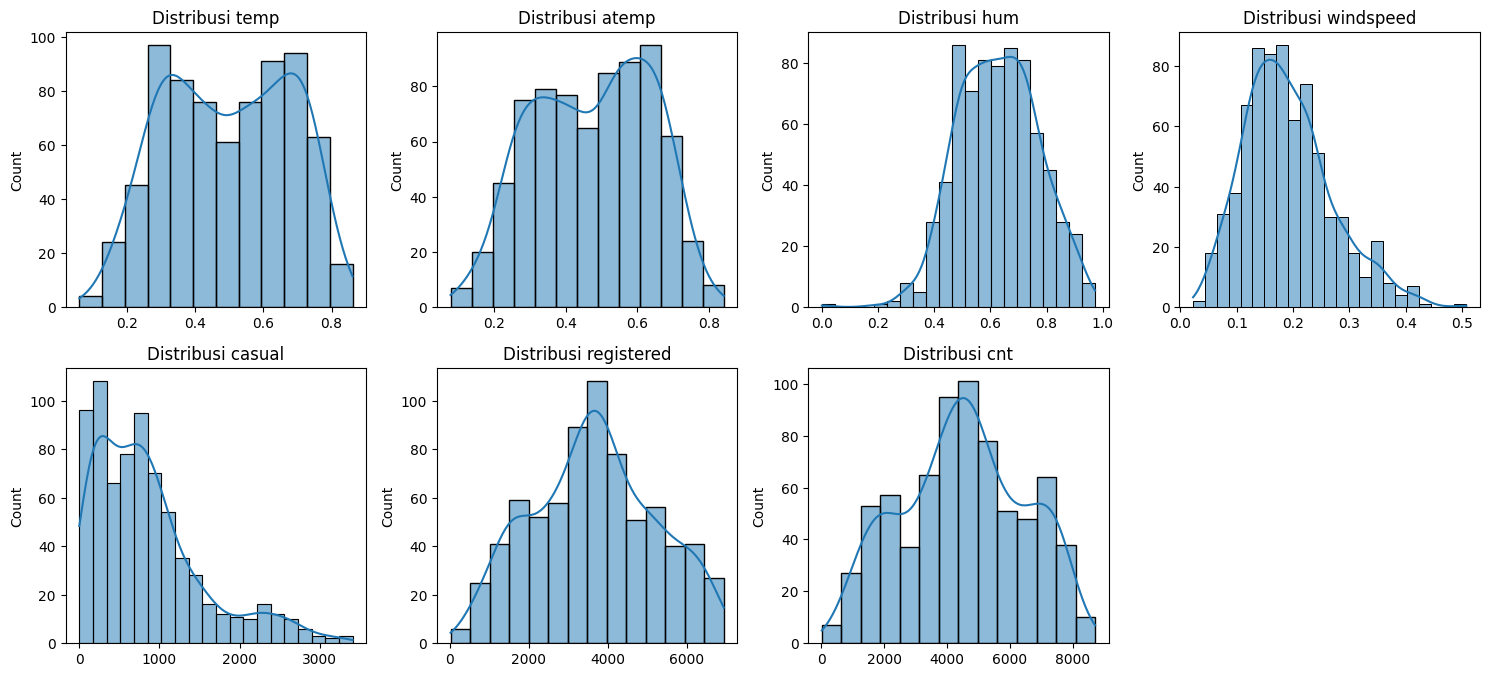

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

print('\nMemvisualisasikan distribusi fitur numerik:')

# Kolom numerik yang relevan (sudah didefinisikan sebelumnya)
# Hapus 'instant' karena hanya indeks
numerical_cols_for_dist = [col for col in df.select_dtypes(include=['float64', 'int64']).columns.tolist() if col not in ['instant']]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_dist):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.xlabel('')
plt.tight_layout()
plt.show()


Memvisualisasikan kolom numerik untuk outlier menggunakan Box Plot:


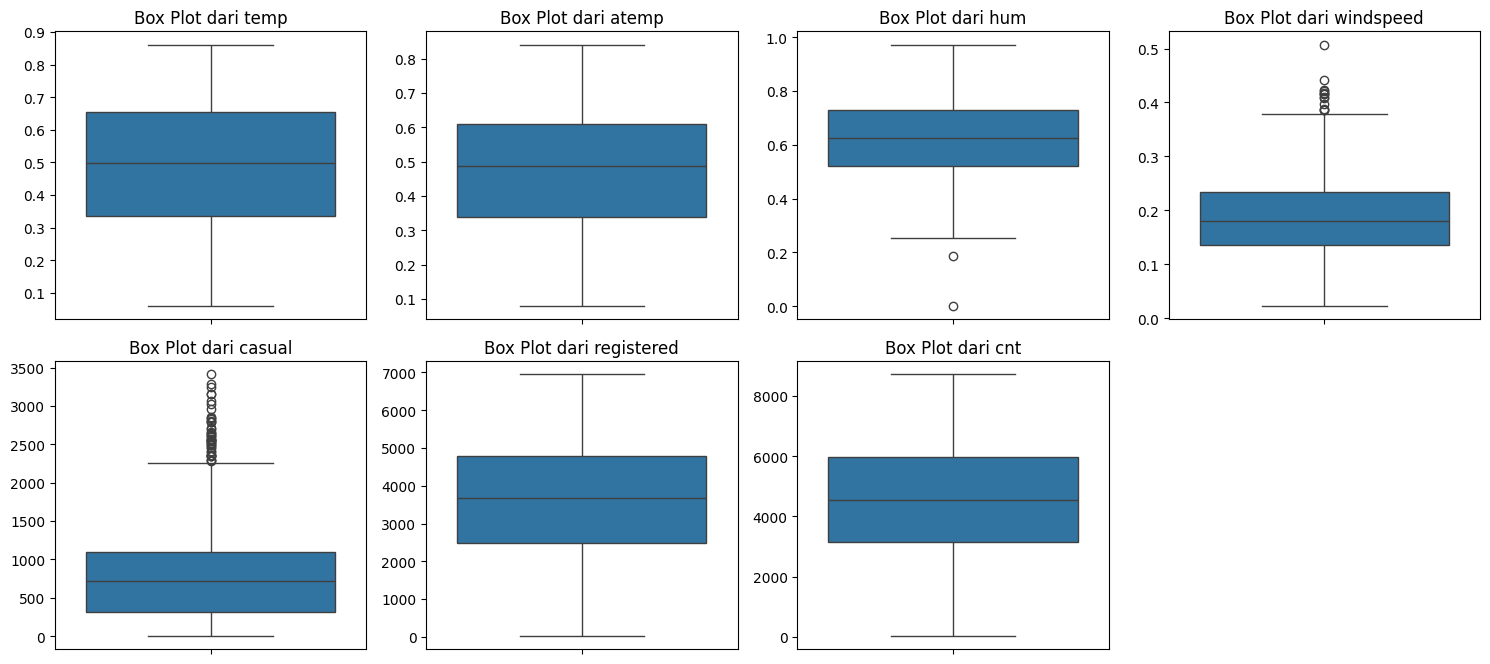

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

print('\nMemvisualisasikan kolom numerik untuk outlier menggunakan Box Plot:')

# Identifikasi kolom numerik (kecuali 'instant' dan 'dteday')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Hapus 'instant' karena hanya indeks dan 'cnt', 'casual', 'registered' adalah variabel target/terkait untuk saat ini
numerical_cols = [col for col in numerical_cols if col not in ['instant']]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Sesuaikan grid subplot sesuai kebutuhan
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot dari {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


Mengeksplorasi hubungan antara fitur kategorikal dan persewaan sepeda (cnt):


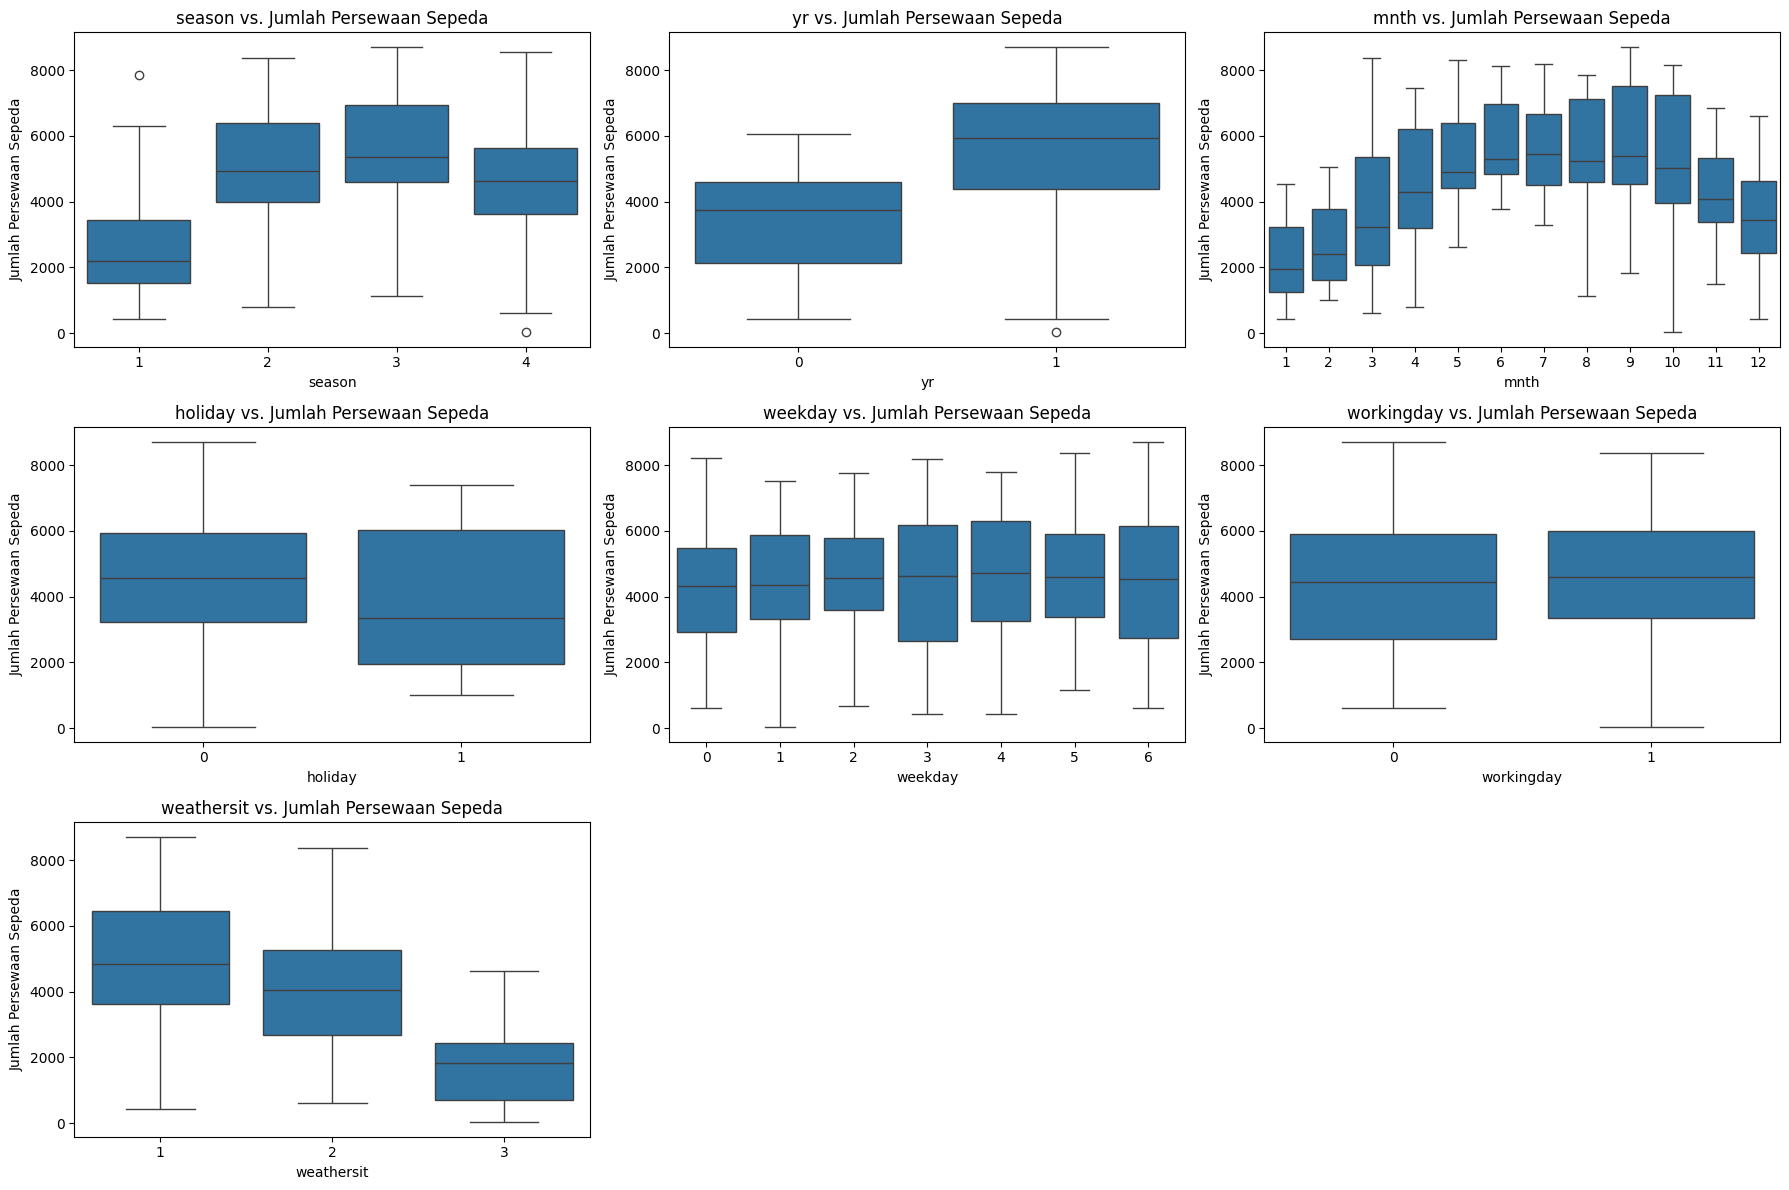

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

print('\nMengeksplorasi hubungan antara fitur kategorikal dan persewaan sepeda (cnt):')

# Kolom kategorikal dari tahap preprocessing sebelumnya
# Diasumsikan 'categorical_cols' sudah didefinisikan

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Sesuaikan grid subplot sesuai kebutuhan
    sns.boxplot(x=col, y='cnt', data=df)
    plt.title(f'{col} vs. Jumlah Persewaan Sepeda')
    plt.xlabel(col)
    plt.ylabel('Jumlah Persewaan Sepeda')
plt.tight_layout()
plt.show()


--- Penanganan Outlier menggunakan IQR (Capping) ---
Outlier di kolom 'temp' telah ditangani dengan capping.
Outlier di kolom 'atemp' telah ditangani dengan capping.
Outlier di kolom 'hum' telah ditangani dengan capping.
Outlier di kolom 'windspeed' telah ditangani dengan capping.

DataFrame setelah penanganan outlier (df_cleaned):


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Memvisualisasikan kolom numerik setelah penanganan outlier:


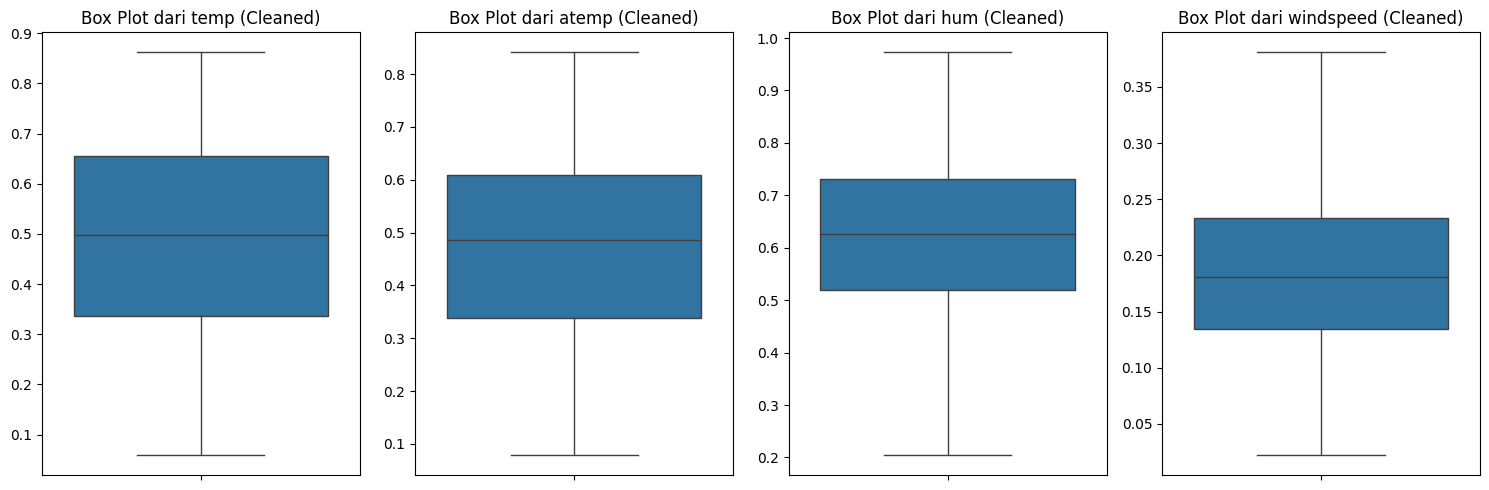

In [66]:
import numpy as np

print('\n--- Penanganan Outlier menggunakan IQR (Capping) ---')

# Kolom numerik yang relevan untuk penanganan outlier
# Kita akan mengecualikan 'instant', 'casual', 'registered', dan 'cnt'
# karena 'instant' adalah ID, dan 'casual', 'registered', 'cnt' adalah target/komponen target
numerical_cols_for_outlier = ['temp', 'atemp', 'hum', 'windspeed']

# Buat salinan DataFrame untuk menghindari perubahan pada DataFrame asli (df)
df_cleaned = df.copy()

for col in numerical_cols_for_outlier:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Terapkan capping: nilai di bawah lower_bound menjadi lower_bound, dan di atas upper_bound menjadi upper_bound
    df_cleaned[col] = np.where(df_cleaned[col] < lower_bound, lower_bound, df_cleaned[col])
    df_cleaned[col] = np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])
    print(f"Outlier di kolom '{col}' telah ditangani dengan capping.")

print('\nDataFrame setelah penanganan outlier (df_cleaned):')
display(df_cleaned.head())

# Anda bisa memvisualisasikan kembali box plot untuk melihat efeknya
import matplotlib.pyplot as plt
import seaborn as sns

print('\nMemvisualisasikan kolom numerik setelah penanganan outlier:')
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_for_outlier):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(y=df_cleaned[col])
    plt.title(f'Box Plot dari {col} (Cleaned)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

## 3.3. One-Hot Encoding Fitur Kategorikal

Setelah penanganan *outlier* dan persiapan fitur numerik, kita akan melanjutkan dengan mengubah fitur kategorikal menjadi format numerik menggunakan *One-Hot Encoding*. Ini penting agar model pembelajaran mesin dapat memprosesnya.



In [67]:
import pandas as pd
import numpy as np

# Definisikan fitur (features_df) dan target (target_series) dari df_cleaned
# Hanya kecualikan 'cnt' dari fitur, sementara 'instant', 'dteday', 'casual' dan 'registered' akan dipertahankan.
features_df = df_cleaned.drop(['cnt'], axis=1)

# Ekstraksi fitur temporal dari 'dteday'
features_df['day_of_year'] = features_df['dteday'].dt.dayofyear
features_df['week_of_year'] = features_df['dteday'].dt.isocalendar().week.astype(int)
features_df['day_of_month'] = features_df['dteday'].dt.day

# Hapus kolom 'dteday' asli setelah fitur temporal diekstrak
features_df = features_df.drop('dteday', axis=1)

target_series = df_cleaned['cnt']

print(f"Bentuk features_df: {features_df.shape}")
print(f"Bentuk target_series: {target_series.shape}")

Bentuk features_df: (731, 17)
Bentuk target_series: (731,)


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asumsi 'features_df', 'target_series', dan 'categorical_cols' sudah tersedia dari sel sebelumnya.

print('\nMelakukan One-Hot Encoding pada fitur kategorikal...')
# Lakukan one-hot encoding untuk fitur kategorikal dari features_df
# Pastikan 'categorical_cols' sudah didefinisikan dengan benar (dari tahap preprocessing)
X_encoded = pd.get_dummies(features_df, columns=categorical_cols, drop_first=True)

# Memastikan semua kolom boolean yang dihasilkan dari One-Hot Encoding dikonversi menjadi integer (0 atau 1)
for col in X_encoded.select_dtypes(include='bool').columns:
    X_encoded[col] = X_encoded[col].astype(int)

print(f"Bentuk X_encoded setelah One-Hot Encoding: {X_encoded.shape}")

# Buat DataFrame baru untuk menghitung matriks korelasi yang diperluas
# dengan menggabungkan fitur yang sudah di-encode dan target (target_series).
df_for_correlation_matrix = X_encoded.copy()
df_for_correlation_matrix['cnt'] = target_series

print("Features (X_encoded) dan Target (target_series) telah siap.")


Melakukan One-Hot Encoding pada fitur kategorikal...
Bentuk X_encoded setelah One-Hot Encoding: (731, 35)
Features (X_encoded) dan Target (target_series) telah siap.



Memvisualisasikan matriks korelasi untuk semua variabel (numerik + kategorikal One-Hot Encoded):


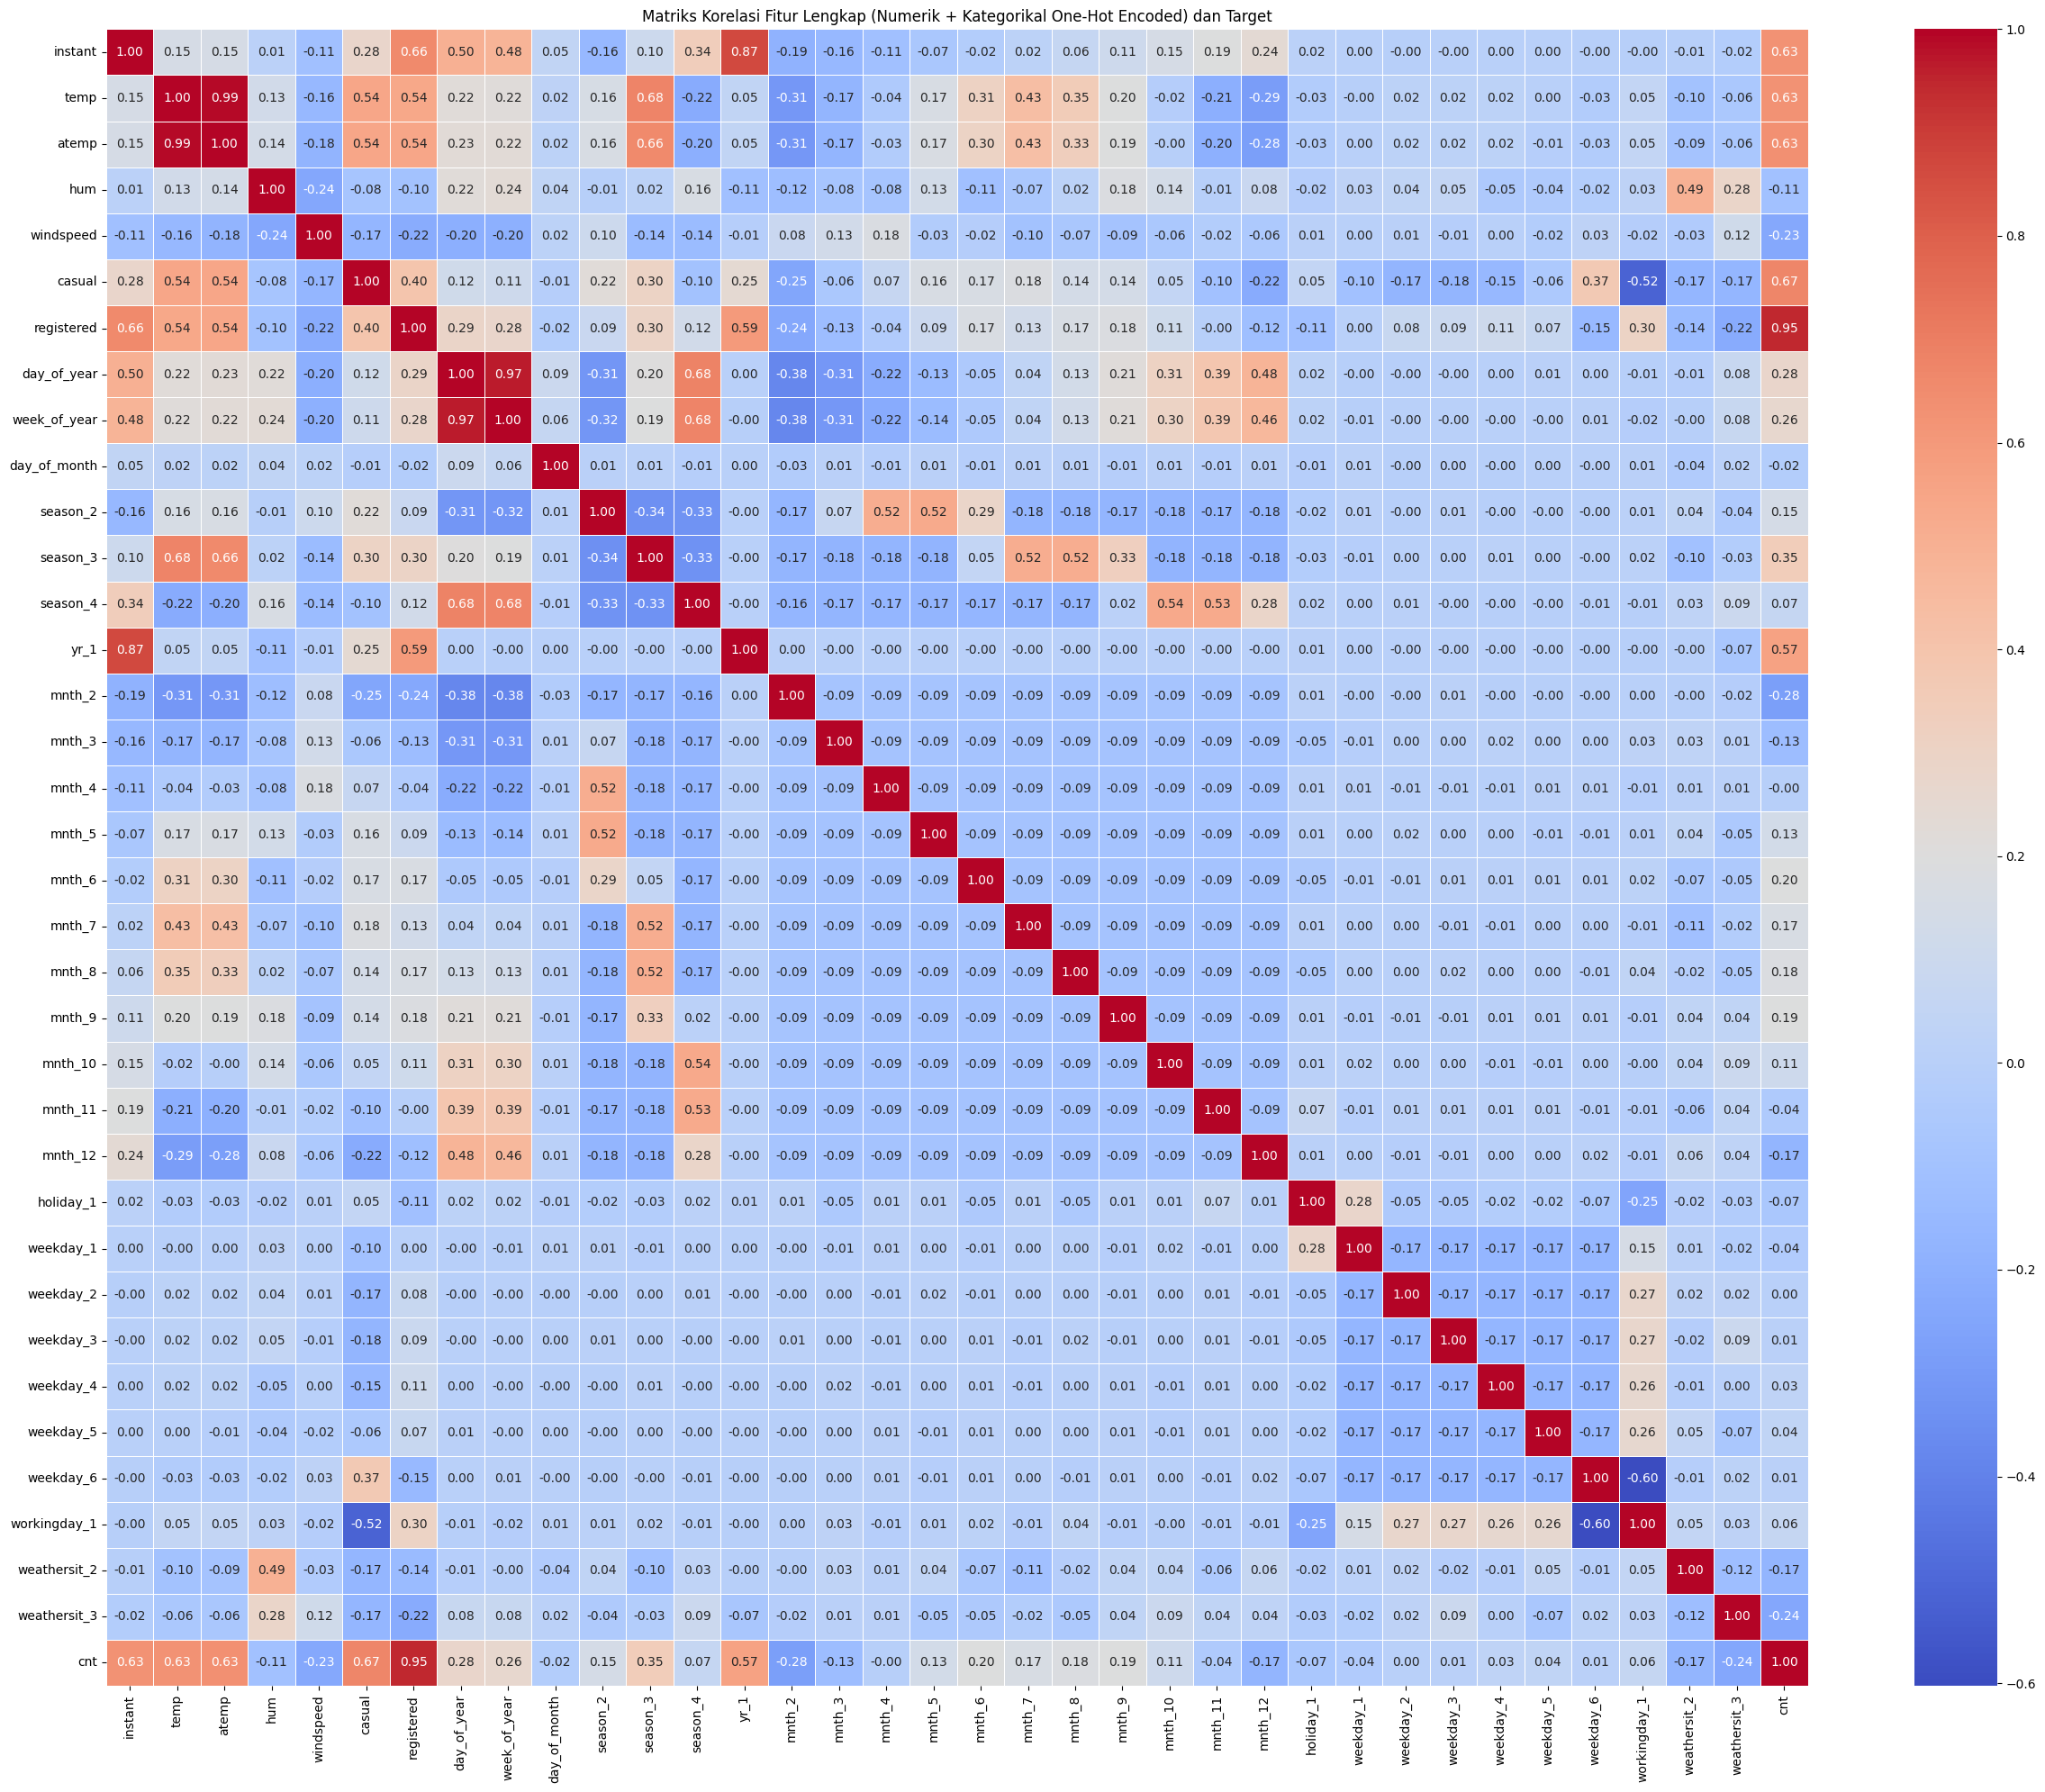


Matriks korelasi lengkap telah divisualisasikan dengan nilai korelasi ditampilkan.


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print('\nMemvisualisasikan matriks korelasi untuk semua variabel (numerik + kategorikal One-Hot Encoded):')

# df_for_correlation_matrix sudah berisi fitur numerik dan kategorikal yang di-One-Hot Encoded, serta target 'cnt'.
# Variabel ini diasumsikan sudah dibuat dan tersedia dari eksekusi sel sebelumnya (kit9cexIbmKX).

# Hitung matriks korelasi dari DataFrame yang diperluas
correlation_matrix_full = df_for_correlation_matrix.corr()

plt.figure(figsize=(25, 20)) # Sesuaikan ukuran figure agar lebih mudah dibaca
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5) # Mengubah annot=False menjadi annot=True
plt.title('Matriks Korelasi Fitur Lengkap (Numerik + Kategorikal One-Hot Encoded) dan Target')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nMatriks korelasi lengkap telah divisualisasikan dengan nilai korelasi ditampilkan.')

In [70]:
print('--- Seleksi Fitur Berdasarkan Korelasi dengan Target (cnt) ---')

# Asumsi 'correlation_matrix_full' dan 'X_encoded' sudah tersedia dari sel sebelumnya

# Dapatkan korelasi semua fitur dengan target 'cnt'
# Pastikan 'cnt' ada di correlation_matrix_full
if 'cnt' not in correlation_matrix_full.columns:
    print("Error: Kolom 'cnt' tidak ditemukan di correlation_matrix_full. Pastikan df_for_correlation_matrix sudah benar.")
else:
    correlation_with_cnt = correlation_matrix_full['cnt'].abs()

    # Hapus 'dteday' dan 'instant' dari `X_encoded` karena tidak relevan untuk training model
    # dan 'dteday' memiliki tipe data datetime yang tidak dapat langsung diproses oleh model.
    X_encoded_processed = X_encoded.drop(columns=['dteday', 'instant'], errors='ignore')

    # Recalculate correlation with `cnt` using the processed `X_encoded_processed`
    # and `target_series` to identify low correlation features from the numerical/one-hot encoded features.
    df_for_correlation_matrix_processed = X_encoded_processed.copy()
    df_for_correlation_matrix_processed['cnt'] = target_series
    correlation_matrix_full_processed = df_for_correlation_matrix_processed.corr()
    correlation_with_cnt_processed = correlation_matrix_full_processed['cnt'].abs()

    low_corr_features = correlation_with_cnt_processed[correlation_with_cnt_processed < 0.08].index.tolist()
    if 'cnt' in low_corr_features:
        low_corr_features.remove('cnt') # Pastikan target tidak dihapus

    # `dteday` and `instant` are already handled by dropping them from `X_encoded_processed`.
    # `features_to_drop_final` now only contains features from `low_corr_features`.
    features_to_drop_final = list(set(low_corr_features))

    print(f"\nFitur yang akan dihapus karena korelasi rendah atau tidak relevan: {features_to_drop_final}")

    # Buat DataFrame baru dengan fitur yang relevan dari X_encoded_processed
    X_filtered = X_encoded_processed.drop(columns=features_to_drop_final, errors='ignore')

    print(f"\nBentuk X_encoded sebelum filter (termasuk dteday dan instant): {X_encoded.shape}")
    print(f"Bentuk X_filtered setelah filter (tanpa dteday, instant, dan korelasi rendah): {X_filtered.shape}")
    print(f"Jumlah fitur yang dihapus: {len(features_to_drop_final) + 2}") # +2 for 'dteday' and 'instant'

    print('\nFitur dengan korelasi rendah atau tidak relevan telah dihapus. X_filtered siap digunakan untuk pembangunan model.')

--- Seleksi Fitur Berdasarkan Korelasi dengan Target (cnt) ---

Fitur yang akan dihapus karena korelasi rendah atau tidak relevan: ['weekday_3', 'weekday_4', 'holiday_1', 'mnth_11', 'weekday_2', 'mnth_4', 'day_of_month', 'workingday_1', 'season_4', 'weekday_6', 'weekday_1', 'weekday_5']

Bentuk X_encoded sebelum filter (termasuk dteday dan instant): (731, 35)
Bentuk X_filtered setelah filter (tanpa dteday, instant, dan korelasi rendah): (731, 22)
Jumlah fitur yang dihapus: 14

Fitur dengan korelasi rendah atau tidak relevan telah dihapus. X_filtered siap digunakan untuk pembangunan model.


## 4. Data Splitting (Pembagian Data)

Pada tahap ini, kita akan membagi dataset menjadi set pelatihan dan pengujian menggunakan beberapa strategi untuk mengevaluasi kinerja model secara komprehensif.

In [71]:
from sklearn.model_selection import train_test_split
import numpy as np

print('Variabel fitur (X_filtered) dan target (target_series) sudah siap dari langkah sebelumnya.')

print('\nMelakukan Pembagian Data (Train-Test Split) dengan berbagai rasio...')
# Pastikan X_filtered sudah tersedia dari sel sebelumnya (setelah One-Hot Encoding dan filter korelasi rendah)

# Pembagian data 80/20
X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20 = train_test_split(
    X_filtered, target_series, test_size=0.2, random_state=42
)
print(f"Bentuk data setelah split 80/20: X_train={X_train_80_20.shape}, X_test={X_test_80_20.shape}")

# Pembagian data 70/30
X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30 = train_test_split(
    X_filtered, target_series, test_size=0.3, random_state=42
)
print(f"Bentuk data setelah split 70/30: X_train={X_train_70_30.shape}, X_test={X_test_70_30.shape}")

# Pembagian data 90/10
X_train_90_10, X_test_90_10, y_train_90_10, y_test_90_10 = train_test_split(
    X_filtered, target_series, test_size=0.1, random_state=42
)
print(f"Bentuk data setelah split 90/10: X_train={X_train_90_10.shape}, X_test={X_test_90_10.shape}")

print('\nPembagian data telah selesai. Variabel X_train/X_test dan y_train/y_test yang baru siap digunakan untuk pelatihan model.')

Variabel fitur (X_filtered) dan target (target_series) sudah siap dari langkah sebelumnya.

Melakukan Pembagian Data (Train-Test Split) dengan berbagai rasio...
Bentuk data setelah split 80/20: X_train=(584, 22), X_test=(147, 22)
Bentuk data setelah split 70/30: X_train=(511, 22), X_test=(220, 22)
Bentuk data setelah split 90/10: X_train=(657, 22), X_test=(74, 22)

Pembagian data telah selesai. Variabel X_train/X_test dan y_train/y_test yang baru siap digunakan untuk pelatihan model.


## 5. Model Building (Pembangunan Model)

Pada tahap ini, kita akan membangun model prediktif menggunakan tiga algoritma yang telah ditentukan: Regression Tree, Support Vector Regression (SVR), dan XGBoost. Kita akan melatih setiap model pada data pelatihan dan membuat prediksi pada data pengujian. Untuk evaluasi awal, kita akan menggunakan pembagian data acak 80/20.

### 5.1. Regression Tree (Decision Tree Regressor)

Kita akan membangun model Regression Tree terlebih dahulu. Model ini relatif mudah diinterpretasikan dan dapat menangkap hubungan non-linear dalam data.

In [72]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print('Membangun dan melatih model Regression Tree untuk ketiga pembagian data...')

# Definisikan model Decision Tree Regressor
dtr = DecisionTreeRegressor(random_state=42)

# Daftar pembagian data (menggunakan X_filtered)
data_splits = {
    "80/20": (X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20),
    "70/30": (X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30),
    "90/10": (X_train_90_10, X_test_90_10, y_train_90_10, y_test_90_10)
}

results = {}

for name, (X_train, X_test, y_train, y_test) in data_splits.items():
    print(f"\n--- Evaluasi untuk Pembagian Data {name} ---")

    # Latih model
    dtr.fit(X_train, y_train)

    # Buat prediksi pada data pelatihan
    y_pred_train = dtr.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)

    # Buat prediksi pada data pengujian
    y_pred_test = dtr.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)

    results[name] = {'RMSE_train': rmse_train, 'R2_train': r2_train, 'RMSE_test': rmse_test, 'R2_test': r2_test}

    # print(f"  [Training Data] Root Mean Squared Error (RMSE): {rmse_train:.3f}")
    # print(f"  [Training Data] R-squared (R2): {r2_train:.3f}")
    print(f"  [Test Data] Root Mean Squared Error (RMSE): {rmse_test:.3f}")
    print(f"  [Test Data] R-squared (R2): {r2_test:.3f}")

print('\nSemua model Regression Tree telah selesai dibangun dan dievaluasi untuk ketiga pembagian data.')

print('\nRingkasan Kinerja Model Decision Tree Regressor:')
for name, metrics in results.items():
    print(f"Pembagian {name}: RMSE (Test) = {metrics['RMSE_test']:.3f}, R2 (Test) = {metrics['R2_test']:.3f}")

Membangun dan melatih model Regression Tree untuk ketiga pembagian data...

--- Evaluasi untuk Pembagian Data 80/20 ---
  [Test Data] Root Mean Squared Error (RMSE): 199.315
  [Test Data] R-squared (R2): 0.990

--- Evaluasi untuk Pembagian Data 70/30 ---
  [Test Data] Root Mean Squared Error (RMSE): 197.419
  [Test Data] R-squared (R2): 0.990

--- Evaluasi untuk Pembagian Data 90/10 ---
  [Test Data] Root Mean Squared Error (RMSE): 192.870
  [Test Data] R-squared (R2): 0.992

Semua model Regression Tree telah selesai dibangun dan dievaluasi untuk ketiga pembagian data.

Ringkasan Kinerja Model Decision Tree Regressor:
Pembagian 80/20: RMSE (Test) = 199.315, R2 (Test) = 0.990
Pembagian 70/30: RMSE (Test) = 197.419, R2 (Test) = 0.990
Pembagian 90/10: RMSE (Test) = 192.870, R2 (Test) = 0.992


In [73]:
from sklearn.ensemble import RandomForestRegressor # Mengubah import dari LinearRegression ke RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print('Membangun dan melatih model Random Forest Regressor untuk ketiga pembagian data...')

# Definisikan model Random Forest Regressor
# Gunakan parameter default sebagai titik awal
rf_reg = RandomForestRegressor(random_state=42)

# Daftar pembagian data (menggunakan X_filtered)
data_splits = {
    "80/20": (X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20),
    "70/30": (X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30),
    "90/10": (X_train_90_10, X_test_90_10, y_train_90_10, y_test_90_10)
}

results_rf_reg = {}

for name, (X_train, X_test, y_train, y_test) in data_splits.items():
    print(f"\n--- Evaluasi untuk Pembagian Data {name} ---")

    # Latih model
    rf_reg.fit(X_train, y_train)

    # Buat prediksi pada data pelatihan
    y_pred_train_rf_reg = rf_reg.predict(X_train)
    rmse_train_rf_reg = np.sqrt(mean_squared_error(y_train, y_pred_train_rf_reg))
    r2_train_rf_reg = r2_score(y_train, y_pred_train_rf_reg)

    # Buat prediksi pada data pengujian
    y_pred_test_rf_reg = rf_reg.predict(X_test)
    rmse_test_rf_reg = np.sqrt(mean_squared_error(y_test, y_pred_test_rf_reg))
    r2_test_rf_reg = r2_score(y_test, y_pred_test_rf_reg)

    results_rf_reg[name] = {'RMSE_train': rmse_train_rf_reg, 'R2_train': r2_train_rf_reg, 'RMSE_test': rmse_test_rf_reg, 'R2_test': r2_test_rf_reg}

    # print(f"  [Training Data] Root Mean Squared Error (RMSE): {rmse_train_rf_reg:.3f}")
    # print(f"  [Training Data] R-squared (R2): {r2_train_rf_reg:.3f}")
    print(f"  [Test Data] Root Mean Squared Error (RMSE): {rmse_test_rf_reg:.3f}")
    print(f"  [Test Data] R-squared (R2): {r2_test_rf_reg:.3f}")

print('\nSemua model Random Forest Regressor telah selesai dibangun dan dievaluasi untuk ketiga pembagian data.')

print('\nRingkasan Kinerja Model Random Forest Regressor:')
for name, metrics in results_rf_reg.items():
    print(f"Pembagian {name}: RMSE (Test) = {metrics['RMSE_test']:.3f}, R2 (Test) = {metrics['R2_test']:.3f}")

Membangun dan melatih model Random Forest Regressor untuk ketiga pembagian data...

--- Evaluasi untuk Pembagian Data 80/20 ---
  [Test Data] Root Mean Squared Error (RMSE): 105.057
  [Test Data] R-squared (R2): 0.997

--- Evaluasi untuk Pembagian Data 70/30 ---
  [Test Data] Root Mean Squared Error (RMSE): 102.038
  [Test Data] R-squared (R2): 0.997

--- Evaluasi untuk Pembagian Data 90/10 ---
  [Test Data] Root Mean Squared Error (RMSE): 92.913
  [Test Data] R-squared (R2): 0.998

Semua model Random Forest Regressor telah selesai dibangun dan dievaluasi untuk ketiga pembagian data.

Ringkasan Kinerja Model Random Forest Regressor:
Pembagian 80/20: RMSE (Test) = 105.057, R2 (Test) = 0.997
Pembagian 70/30: RMSE (Test) = 102.038, R2 (Test) = 0.997
Pembagian 90/10: RMSE (Test) = 92.913, R2 (Test) = 0.998


### 5.3. XGBoost Regressor

Terakhir, kita akan mengimplementasikan model XGBoost. XGBoost adalah algoritma *ensemble* yang sangat populer karena kinerjanya yang tinggi dan kemampuannya menangani berbagai jenis data.

In [74]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print('Membangun dan melatih model XGBoost Regressor untuk ketiga pembagian data...')

# Inisialisasi model XGBoost Regressor
# Kita bisa memulai dengan parameter default atau beberapa parameter dasar
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

# Daftar pembagian data (menggunakan X_filtered)
data_splits = {
    "80/20": (X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20),
    "70/30": (X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30),
    "90/10": (X_train_90_10, X_test_90_10, y_train_90_10, y_test_90_10)
}

results_xgb = {}

for name, (X_train, X_test, y_train, y_test) in data_splits.items():
    print(f"\n--- Evaluasi untuk Pembagian Data {name} ---")

    # Latih model
    xgb_reg.fit(X_train, y_train)

    # Buat prediksi pada data pelatihan
    y_pred_train_xgb = xgb_reg.predict(X_train)
    rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
    r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

    # Buat prediksi pada data pengujian
    y_pred_test_xgb = xgb_reg.predict(X_test)
    rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
    r2_test_xgb = r2_score(y_test, y_pred_test_xgb)

    results_xgb[name] = {'RMSE_train': rmse_train_xgb, 'R2_train': r2_train_xgb, 'RMSE_test': rmse_test_xgb, 'R2_test': r2_test_xgb}

    # print(f"  [Training Data] Root Mean Squared Error (RMSE): {rmse_train_xgb:.3f}")
    # print(f"  [Training Data] R-squared (R2): {r2_train_xgb:.3f}")
    print(f"  [Test Data] Root Mean Squared Error (RMSE): {rmse_test_xgb:.3f}")
    print(f"  [Test Data] R-squared (R2): {r2_test_xgb:.3f}")

print('\nSemua model XGBoost Regressor telah selesai dibangun dan dievaluasi untuk ketiga pembagian data.')

print('\nRingkasan Kinerja Model XGBoost Regressor:')
for name, metrics in results_xgb.items():
    print(f"Pembagian {name}: RMSE (Test) = {metrics['RMSE_test']:.3f}, R2 (Test) = {metrics['R2_test']:.3f}")

Membangun dan melatih model XGBoost Regressor untuk ketiga pembagian data...

--- Evaluasi untuk Pembagian Data 80/20 ---
  [Test Data] Root Mean Squared Error (RMSE): 126.169
  [Test Data] R-squared (R2): 0.996

--- Evaluasi untuk Pembagian Data 70/30 ---
  [Test Data] Root Mean Squared Error (RMSE): 122.822
  [Test Data] R-squared (R2): 0.996

--- Evaluasi untuk Pembagian Data 90/10 ---
  [Test Data] Root Mean Squared Error (RMSE): 133.862
  [Test Data] R-squared (R2): 0.996

Semua model XGBoost Regressor telah selesai dibangun dan dievaluasi untuk ketiga pembagian data.

Ringkasan Kinerja Model XGBoost Regressor:
Pembagian 80/20: RMSE (Test) = 126.169, R2 (Test) = 0.996
Pembagian 70/30: RMSE (Test) = 122.822, R2 (Test) = 0.996
Pembagian 90/10: RMSE (Test) = 133.862, R2 (Test) = 0.996


In [75]:
import pandas as pd
import numpy as np

print('--- Rekapitulasi dan Perbandingan Kinerja Model (Sebelum Tuning) ---')

# Kumpulkan semua hasil ke dalam satu struktur data
all_results_before_tuning = {
    'Model': [],
    'Data Split': [],
    'RMSE_test': [],
    'R2_test': [],
    'MSE_test': []
}

# Tambahkan hasil Decision Tree Regressor (dari variabel 'results')
for split, metrics in results.items():
    all_results_before_tuning['Model'].append('Decision Tree Regressor')
    all_results_before_tuning['Data Split'].append(split)
    all_results_before_tuning['RMSE_test'].append(metrics['RMSE_test'])
    all_results_before_tuning['R2_test'].append(metrics['R2_test'])
    all_results_before_tuning['MSE_test'].append(np.power(metrics['RMSE_test'], 2))

# Tambahkan hasil Random Forest Regressor (dari variabel 'results_rf_reg')
for split, metrics in results_rf_reg.items():
    all_results_before_tuning['Model'].append('Random Forest Regressor')
    all_results_before_tuning['Data Split'].append(split)
    all_results_before_tuning['RMSE_test'].append(metrics['RMSE_test'])
    all_results_before_tuning['R2_test'].append(metrics['R2_test'])
    all_results_before_tuning['MSE_test'].append(np.power(metrics['RMSE_test'], 2))

# Tambahkan hasil XGBoost Regressor (dari variabel 'results_xgb')
for split, metrics in results_xgb.items():
    all_results_before_tuning['Model'].append('XGBoost Regressor')
    all_results_before_tuning['Data Split'].append(split)
    all_results_before_tuning['RMSE_test'].append(metrics['RMSE_test'])
    all_results_before_tuning['R2_test'].append(metrics['R2_test'])
    all_results_before_tuning['MSE_test'].append(np.power(metrics['RMSE_test'], 2))

# Buat DataFrame dari hasil
comparison_df_before_tuning = pd.DataFrame(all_results_before_tuning)

# Tampilkan DataFrame dengan format 3 digit desimal untuk kolom numerik
display(comparison_df_before_tuning.round(3))

--- Rekapitulasi dan Perbandingan Kinerja Model (Sebelum Tuning) ---


,Model,Data Split,RMSE_test,R2_test,MSE_test
0,Decision Tree Regressor,80/20,199.315,0.990,39726.578
1,Decision Tree Regressor,70/30,197.419,0.990,38974.173
2,Decision Tree Regressor,90/10,192.870,0.992,37198.905
3,Random Forest Regressor,80/20,105.057,0.997,11036.942
4,Random Forest Regressor,70/30,102.038,0.997,10411.669
5,Random Forest Regressor,90/10,92.913,0.998,8632.858
6,XGBoost Regressor,80/20,126.169,0.996,15918.635
7,XGBoost Regressor,70/30,122.822,0.996,15085.186
8,XGBoost Regressor,90/10,133.862,0.996,17919.055


## 6. Hyperparameter Tuning (Penyetelan Hyperparameter)

Pada tahap ini, kita akan melakukan penyetelan hyperparameter untuk model-model yang telah kita bangun, terutama untuk meningkatkan kinerjanya. Kita akan menggunakan teknik seperti *Grid Search* atau *Random Search* untuk menemukan kombinasi parameter terbaik. Untuk memulai, kita akan fokus pada model XGBoost yang menunjukkan kinerja awal terbaik.

gnhhhhhhfffffffslaoao### 6.1. Hyperparameter Tuning untuk XGBoost Regressor

Kita akan menggunakan `GridSearchCV` untuk mencari hyperparameter optimal bagi XGBoost Regressor. Parameter yang akan kita *tune* meliputi `n_estimators`, `max_depth`, `learning_rate`, dan `subsample`.

In [76]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb # Pastikan xgboost diimpor di sini juga jika belum
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

print('Memulai Hyperparameter Tuning untuk XGBoost Regressor pada ketiga pembagian data...')

# Definisikan parameter grid yang diperluas
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3,4,5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

# Daftar pembagian data
data_splits = {
    "80/20": (X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20),
    "70/30": (X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30),
    "90/10": (X_train_90_10, X_test_90_10, y_train_90_10, y_test_90_10)
}

results_tuned_xgb = {}
best_xgb_models = {}

for name, (X_train, X_test, y_train, y_test) in data_splits.items():
    print(f"\n--- Hyperparameter Tuning untuk Pembagian Data {name} ---")

    # Inisialisasi model XGBoost
    xgb_tuned = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

    # Inisialisasi GridSearchCV
    grid_search = GridSearchCV(
        estimator=xgb_tuned,
        param_grid=param_grid,
        cv=3, # Menggunakan 3-fold cross-validation
        n_jobs=-1, # Menggunakan semua core CPU yang tersedia
        verbose=2, # Menampilkan progress lebih detail
        scoring='neg_mean_squared_error' # Metrik evaluasi
    )

    # Lakukan Grid Search pada data pelatihan saat ini
    grid_search.fit(X_train, y_train)

    print(f"\nHyperparameter Tuning selesai untuk {name}. Hasil terbaik:")
    print(f"  Best Parameters: {grid_search.best_params_}")
    print(f"  Best RMSE (dari CV): {-grid_search.best_score_:.2f}")

    # Dapatkan model terbaik
    best_xgb_model_for_split = grid_search.best_estimator_
    best_xgb_models[name] = best_xgb_model_for_split

    print(f"\nMengevaluasi model XGBoost terbaik pada data pengujian {name}:")
    # Buat prediksi dengan model terbaik pada data pelatihan
    y_pred_train_best_xgb = best_xgb_model_for_split.predict(X_train)
    rmse_train_best_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_best_xgb))
    r2_train_best_xgb = r2_score(y_train, y_pred_train_best_xgb)

    # Buat prediksi dengan model terbaik pada data pengujian
    y_pred_test_best_xgb = best_xgb_model_for_split.predict(X_test)
    rmse_test_best_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test_best_xgb))
    r2_test_best_xgb = r2_score(y_test, y_pred_test_best_xgb)

    results_tuned_xgb[name] = {
        'Best Parameters': grid_search.best_params_,
        'RMSE_train': rmse_train_best_xgb, 'R2_train': r2_train_best_xgb,
        'RMSE_test': rmse_test_best_xgb, 'R2_test': r2_test_best_xgb
    }

    # print(f"  [Training Data] Root Mean Squared Error (RMSE) Model Terbaik: {rmse_train_best_xgb:.2f}")
    # print(f"  [Training Data] R-squared (R2) Model Terbaik: {r2_train_best_xgb:.2f}")
    print(f"  [Test Data] Root Mean Squared Error (RMSE) Model Terbaik: {rmse_test_best_xgb:.3f}")
    print(f"  [Test Data] R-squared (R2) Model Terbaik: {r2_test_best_xgb:.3f}")

print('\nHyperparameter Tuning untuk XGBoost Regressor telah selesai pada semua pembagian data.')

print('\nRingkasan Kinerja Model XGBoost Regressor (Setelah Tuning):')
for name, metrics in results_tuned_xgb.items():
    print(f"Pembagian {name}: RMSE (Test) = {metrics['RMSE_test']:.2f}, R2 (Test) = {metrics['R2_test']:.2f}, Best Params = {metrics['Best Parameters']}")


Memulai Hyperparameter Tuning untuk XGBoost Regressor pada ketiga pembagian data...

--- Hyperparameter Tuning untuk Pembagian Data 80/20 ---
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Hyperparameter Tuning selesai untuk 80/20. Hasil terbaik:
  Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.9}
  Best RMSE (dari CV): 19273.89

Mengevaluasi model XGBoost terbaik pada data pengujian 80/20:
  [Test Data] Root Mean Squared Error (RMSE) Model Terbaik: 92.946
  [Test Data] R-squared (R2) Model Terbaik: 0.998

--- Hyperparameter Tuning untuk Pembagian Data 70/30 ---
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Hyperparameter Tuning selesai untuk 70/30. Hasil terbaik:
  Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
  Best RMSE (dari CV): 18643.04

Mengevaluasi model XGBoost terbaik pada data pengujian 70/30:
  [Test Data] Root Mean Squared Error (RMSE) Model Terbai

### 6.2. Hyperparameter Tuning untuk Regression Tree Regressor

Kita akan menggunakan `GridSearchCV` untuk mencari hyperparameter optimal bagi `DecisionTreeRegressor`. Parameter yang akan kita *tune* meliputi `max_depth`, `min_samples_split`, dan `min_samples_leaf`.

In [77]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print('Memulai Hyperparameter Tuning untuk Regression Tree Regressor pada ketiga pembagian data...')

# Definisikan parameter grid yang diperluas
param_grid_dtr = {
    'max_depth': [3, 5, 8],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2, 3, 4, 5, 8, 10]
}

# Daftar pembagian data (mengambil dari langkah sebelumnya)
data_splits = {
    "80/20": (X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20),
    "70/30": (X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30),
    "90/10": (X_train_90_10, X_test_90_10, y_train_90_10, y_test_90_10)
}

results_tuned_dtr = {}
best_dtr_models = {}

for name, (X_train, X_test, y_train, y_test) in data_splits.items():
    print(f"\n--- Hyperparameter Tuning untuk Pembagian Data {name} ---")

    # Inisialisasi model Decision Tree
    dtr_tuned = DecisionTreeRegressor(random_state=40)

    # Inisialisasi GridSearchCV
    grid_search_dtr = GridSearchCV(
        estimator=dtr_tuned,
        param_grid=param_grid_dtr,
        cv=3, # Menggunakan 3-fold cross-validation
        n_jobs=-1, # Menggunakan semua core CPU yang tersedia
        verbose=2, # Menampilkan progress lebih detail
        scoring='neg_mean_squared_error' # Metrik evaluasi
    )

    # Lakukan Grid Search pada data pelatihan saat ini
    grid_search_dtr.fit(X_train, y_train)

    print(f"\nHyperparameter Tuning selesai untuk {name}. Hasil terbaik:")
    print(f"  Best Parameters: {grid_search_dtr.best_params_}")
    print(f"  Best RMSE (dari CV): {np.sqrt(-grid_search_dtr.best_score_):.3f}")

    # Dapatkan model terbaik
    best_dtr_model_for_split = grid_search_dtr.best_estimator_
    best_dtr_models[name] = best_dtr_model_for_split

    print(f"\nMengevaluasi model Regression Tree terbaik pada data pengujian {name}:")
    # Buat prediksi dengan model terbaik pada data pelatihan
    y_pred_train_best_dtr = best_dtr_model_for_split.predict(X_train)
    rmse_train_best_dtr = np.sqrt(mean_squared_error(y_train, y_pred_train_best_dtr))
    r2_train_best_dtr = r2_score(y_train, y_pred_train_best_dtr)

    # Buat prediksi dengan model terbaik pada data pengujian
    y_pred_test_best_dtr = best_dtr_model_for_split.predict(X_test)
    rmse_test_best_dtr = np.sqrt(mean_squared_error(y_test, y_pred_test_best_dtr))
    r2_test_best_dtr = r2_score(y_test, y_pred_test_best_dtr)

    results_tuned_dtr[name] = {
        'Best Parameters': grid_search_dtr.best_params_,
        'RMSE_train': rmse_train_best_dtr, 'R2_train': r2_train_best_dtr,
        'RMSE_test': rmse_test_best_dtr, 'R2_test': r2_test_best_dtr
    }

    # print(f"  [Training Data] Root Mean Squared Error (RMSE) Model Terbaik: {rmse_train_best_dtr:.3f}")
    # print(f"  [Training Data] R-squared (R2) Model Terbaik: {r2_train_best_dtr:.3f}")
    print(f"  [Test Data] Root Mean Squared Error (RMSE) Model Terbaik: {rmse_test_best_dtr:.3f}")
    print(f"  [Test Data] R-squared (R2) Model Terbaik: {r2_test_best_dtr:.3f}")

print('\nHyperparameter Tuning untuk Regression Tree Regressor telah selesai pada semua pembagian data.')

print('\nRingkasan Kinerja Model Regression Tree Regressor (Setelah Tuning):')
for name, metrics in results_tuned_dtr.items():
    print(f"Pembagian {name}: RMSE (Test) = {metrics['RMSE_test']:.3f}, R2 (Test) = {metrics['R2_test']:.3f}, Best Params = {metrics['Best Parameters']}")

Memulai Hyperparameter Tuning untuk Regression Tree Regressor pada ketiga pembagian data...

--- Hyperparameter Tuning untuk Pembagian Data 80/20 ---
Fitting 3 folds for each of 63 candidates, totalling 189 fits

Hyperparameter Tuning selesai untuk 80/20. Hasil terbaik:
  Best Parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 5}
  Best RMSE (dari CV): 255.965

Mengevaluasi model Regression Tree terbaik pada data pengujian 80/20:
  [Test Data] Root Mean Squared Error (RMSE) Model Terbaik: 194.832
  [Test Data] R-squared (R2) Model Terbaik: 0.991

--- Hyperparameter Tuning untuk Pembagian Data 70/30 ---
Fitting 3 folds for each of 63 candidates, totalling 189 fits

Hyperparameter Tuning selesai untuk 70/30. Hasil terbaik:
  Best Parameters: {'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 7}
  Best RMSE (dari CV): 284.582

Mengevaluasi model Regression Tree terbaik pada data pengujian 70/30:
  [Test Data] Root Mean Squared Error (RMSE) Model Terbaik: 19

### 6.3. Hyperparameter Tuning untuk Random Forest Regressor

Kita akan menggunakan `GridSearchCV` untuk mencari hyperparameter optimal bagi `RandomForestRegressor`. Parameter yang akan kita *tune* meliputi `n_estimators`, `max_depth`, `min_samples_split`, dan `min_samples_leaf`.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print('Memulai Hyperparameter Tuning untuk Random Forest Regressor pada ketiga pembagian data...')

# Definisikan parameter grid yang diperluas untuk Random Forest Regressor
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 8, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Daftar pembagian data (mengambil dari langkah sebelumnya)
data_splits = {
    "80/20": (X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20),
    "70/30": (X_train_70_30, X_test_70_30, y_train_70_30, y_test_70_30),
    "90/10": (X_train_90_10, X_test_90_10, y_train_90_10, y_test_90_10)
}

results_tuned_rf = {}
best_rf_models = {}

for name, (X_train, X_test, y_train, y_test) in data_splits.items():
    print(f"\n--- Hyperparameter Tuning untuk Pembagian Data {name} ---")

    # Inisialisasi model Random Forest
    rf_tuned = RandomForestRegressor(random_state=42)

    # Inisialisasi GridSearchCV
    grid_search_rf = GridSearchCV(
        estimator=rf_tuned,
        param_grid=param_grid_rf,
        cv=3, # Menggunakan 3-fold cross-validation
        n_jobs=-1, # Menggunakan semua core CPU yang tersedia
        verbose=2, # Menampilkan progress lebih detail
        scoring='neg_mean_squared_error' # Metrik evaluasi
    )

    # Lakukan Grid Search pada data pelatihan saat ini
    grid_search_rf.fit(X_train, y_train)

    print(f"\nHyperparameter Tuning selesai untuk {name}. Hasil terbaik:")
    print(f"  Best Parameters: {grid_search_rf.best_params_}")
    print(f"  Best RMSE (dari CV): {np.sqrt(-grid_search_rf.best_score_):.3f}") # Menggunakan sqrt untuk RMSE

    # Dapatkan model terbaik
    best_rf_model_for_split = grid_search_rf.best_estimator_
    best_rf_models[name] = best_rf_model_for_split

    print(f"\nMengevaluasi model Random Forest terbaik pada data pengujian {name}:")
    # Buat prediksi dengan model terbaik pada data pelatihan
    y_pred_train_best_rf = best_rf_model_for_split.predict(X_train)
    rmse_train_best_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_best_rf))
    r2_train_best_rf = r2_score(y_train, y_pred_train_best_rf)

    # Buat prediksi dengan model terbaik pada data pengujian
    y_pred_test_best_rf = best_rf_model_for_split.predict(X_test)
    rmse_test_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_best_rf))
    r2_test_best_rf = r2_score(y_test, y_pred_test_best_rf)

    results_tuned_rf[name] = {
        'Best Parameters': grid_search_rf.best_params_,
        'RMSE_train': rmse_train_best_rf, 'R2_train': r2_train_best_rf,
        'RMSE_test': rmse_test_best_rf, 'R2_test': r2_test_best_rf
    }

    # print(f"  [Training Data] Root Mean Squared Error (RMSE) Model Terbaik: {rmse_train_best_rf:.3f}")
    # print(f"  [Training Data] R-squared (R2) Model Terbaik: {r2_train_best_rf:.3f}")
    print(f"  [Test Data] Root Mean Squared Error (RMSE) Model Terbaik: {rmse_test_best_rf:.3f}")
    print(f"  [Test Data] R-squared (R2) Model Terbaik: {r2_test_best_rf:.3f}")

print('\nHyperparameter Tuning untuk Random Forest Regressor telah selesai pada semua pembagian data.')

print('\nRingkasan Kinerja Model Random Forest Regressor (Setelah Tuning):')
for name, metrics in results_tuned_rf.items():
    print(f"Pembagian {name}: RMSE (Test) = {metrics['RMSE_test']:.3f}, R2 (Test) = {metrics['R2_test']:.3f}, Best Params = {metrics['Best Parameters']}")

Memulai Hyperparameter Tuning untuk Random Forest Regressor pada ketiga pembagian data...

--- Hyperparameter Tuning untuk Pembagian Data 80/20 ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print('Memulai evaluasi model pada pembagian data 70/30...')

# --- Evaluasi XGBoost Terbaik ---
print('\n--- XGBoost Regressor (Tuned) ---')
# Pastikan menggunakan model terbaik untuk split 70/30
best_xgb_model_70_30 = best_xgb_models['70/30']
y_pred_xgb_70_30 = best_xgb_model_70_30.predict(X_test_70_30)
rmse_xgb_70_30 = np.sqrt(mean_squared_error(y_test_70_30, y_pred_xgb_70_30))
r2_xgb_70_30 = r2_score(y_test_70_30, y_pred_xgb_70_30)
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_70_30:.3f}")
print(f"  R-squared (R2): {r2_xgb_70_30:.3f}")

# --- Evaluasi Regression Tree Terbaik ---
print('\n--- Regression Tree Regressor (Tuned) ---')
# Pastikan menggunakan model terbaik untuk split 70/30
best_dtr_model_70_30 = best_dtr_models['70/30']
y_pred_dtr_70_30 = best_dtr_model_70_30.predict(X_test_70_30)
rmse_dtr_70_30 = np.sqrt(mean_squared_error(y_test_70_30, y_pred_dtr_70_30))
r2_dtr_70_30 = r2_score(y_test_70_30, y_pred_dtr_70_30)
print(f"  Root Mean Squared Error (RMSE): {rmse_dtr_70_30:.3f}")
print(f"  R-squared (R2): {r2_dtr_70_30:.3f}")

# --- Evaluasi Random Forest Regressor Terbaik ---
print('\n--- Random Forest Regressor (Tuned) ---')
# Pastikan menggunakan model terbaik untuk split 70/30
best_rf_model_70_30 = best_rf_models['70/30']
y_pred_rf_70_30 = best_rf_model_70_30.predict(X_test_70_30)
rmse_rf_70_30 = np.sqrt(mean_squared_error(y_test_70_30, y_pred_rf_70_30))
r2_rf_70_30 = r2_score(y_test_70_30, y_pred_rf_70_30)
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_70_30:.3f}")
print(f"  R-squared (R2): {r2_rf_70_30:.3f}")

print('\nEvaluasi model pada pembagian data 70/30 selesai.')

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print('Memulai evaluasi model pada pembagian data 90/10...')

# --- Evaluasi XGBoost Terbaik ---
print('\n--- XGBoost Regressor (Tuned) ---')
# Pastikan menggunakan model terbaik untuk split 90/10
best_xgb_model_90_10 = best_xgb_models['90/10']
y_pred_xgb_90_10 = best_xgb_model_90_10.predict(X_test_90_10)
rmse_xgb_90_10 = np.sqrt(mean_squared_error(y_test_90_10, y_pred_xgb_90_10))
r2_xgb_90_10 = r2_score(y_test_90_10, y_pred_xgb_90_10)
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_90_10:.3f}")
print(f"  R-squared (R2): {r2_xgb_90_10:.3f}")

# --- Evaluasi Regression Tree Terbaik ---
print('\n--- Regression Tree Regressor (Tuned) ---')
# Pastikan menggunakan model terbaik untuk split 90/10
best_dtr_model_90_10 = best_dtr_models['90/10']
y_pred_dtr_90_10 = best_dtr_model_90_10.predict(X_test_90_10)
rmse_dtr_90_10 = np.sqrt(mean_squared_error(y_test_90_10, y_pred_dtr_90_10))
r2_dtr_90_10 = r2_score(y_test_90_10, y_pred_dtr_90_10)
print(f"  Root Mean Squared Error (RMSE): {rmse_dtr_90_10:.3f}")
print(f"  R-squared (R2): {r2_dtr_90_10:.3f}")

# --- Evaluasi Random Forest Regressor Terbaik ---
print('\n--- Random Forest Regressor (Tuned) ---')
# Pastikan menggunakan model terbaik untuk split 90/10
best_rf_model_90_10 = best_rf_models['90/10']
y_pred_rf_90_10 = best_rf_model_90_10.predict(X_test_90_10)
rmse_rf_90_10 = np.sqrt(mean_squared_error(y_test_90_10, y_pred_rf_90_10))
r2_rf_90_10 = r2_score(y_test_90_10, y_pred_rf_90_10)
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_90_10:.3f}")
print(f"  R-squared (R2): {r2_rf_90_10:.3f}")

print('\nEvaluasi model pada pembagian data 90/10 selesai.')

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print('Memulai evaluasi model pada pembagian data 80/20...')

# --- Evaluasi XGBoost Terbaik ---
print('\n--- XGBoost Regressor (Tuned) ---')
# Pastikan menggunakan model terbaik untuk split 80/20
best_xgb_model_80_20 = best_xgb_models['80/20']
y_pred_xgb_80_20 = best_xgb_model_80_20.predict(X_test_80_20)
rmse_xgb_80_20 = np.sqrt(mean_squared_error(y_test_80_20, y_pred_xgb_80_20))
r2_xgb_80_20 = r2_score(y_test_80_20, y_pred_xgb_80_20)
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_80_20:.3f}")
print(f"  R-squared (R2): {r2_xgb_80_20:.3f}")

# --- Evaluasi Regression Tree Terbaik ---
print('\n--- Regression Tree Regressor (Tuned) ---')
# Pastikan menggunakan model terbaik untuk split 80/20
best_dtr_model_80_20 = best_dtr_models['80/20']
y_pred_dtr_80_20 = best_dtr_model_80_20.predict(X_test_80_20)
rmse_dtr_80_20 = np.sqrt(mean_squared_error(y_test_80_20, y_pred_dtr_80_20))
r2_dtr_80_20 = r2_score(y_test_80_20, y_pred_dtr_80_20)
print(f"  Root Mean Squared Error (RMSE): {rmse_dtr_80_20:.3f}")
print(f"  R-squared (R2): {r2_dtr_80_20:.3f}")

# --- Evaluasi Random Forest Regressor Terbaik ---
print('\n--- Random Forest Regressor (Tuned) ---')
# Pastikan menggunakan model terbaik untuk split 80/20
best_rf_model_80_20 = best_rf_models['80/20']
y_pred_rf_80_20 = best_rf_model_80_20.predict(X_test_80_20)
rmse_rf_80_20 = np.sqrt(mean_squared_error(y_test_80_20, y_pred_rf_80_20))
r2_rf_80_20 = r2_score(y_test_80_20, y_pred_rf_80_20)
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_80_20:.3f}")
print(f"  R-squared (R2): {r2_rf_80_20:.3f}")

print('\nEvaluasi model pada pembagian data 80/20 selesai.')

In [ ]:
import pandas as pd
import numpy as np # Import numpy for power function

print('\n--- Rekapitulasi dan Perbandingan Kinerja Model (Setelah Tuning) ---')

# Kumpulkan semua hasil ke dalam satu struktur data
all_results = {
    'Model': [],
    'Data Split': [],
    # 'RMSE_train': [],
    # 'R2_train': [],
    # 'MSE_train': [], # Add MSE_train column
    'RMSE_test': [],
    'R2_test': [],
    'MSE_test': [],  # Add MSE_test column
    'Best Parameters': []
}

# Tambahkan hasil XGBoost
for split, metrics in results_tuned_xgb.items():
    all_results['Model'].append('XGBoost Regressor')
    all_results['Data Split'].append(split)
    # all_results['RMSE_train'].append(metrics['RMSE_train'])
    # all_results['R2_train'].append(metrics['R2_train'])
    all_results['RMSE_test'].append(metrics['RMSE_test'])
    all_results['R2_test'].append(metrics['R2_test'])
    # all_results['MSE_train'].append(np.power(metrics['RMSE_train'], 2)) # Calculate MSE
    all_results['MSE_test'].append(np.power(metrics['RMSE_test'], 2))   # Calculate MSE
    all_results['Best Parameters'].append(metrics['Best Parameters'])

# Tambahkan hasil Decision Tree Regressor
for split, metrics in results_tuned_dtr.items():
    all_results['Model'].append('Decision Tree Regressor')
    all_results['Data Split'].append(split)
    # all_results['RMSE_train'].append(metrics['RMSE_train'])
    # all_results['R2_train'].append(metrics['R2_train'])
    all_results['RMSE_test'].append(metrics['RMSE_test'])
    all_results['R2_test'].append(metrics['R2_test'])
    # all_results['MSE_train'].append(np.power(metrics['RMSE_train'], 2)) # Calculate MSE
    all_results['MSE_test'].append(np.power(metrics['RMSE_test'], 2))   # Calculate MSE
    all_results['Best Parameters'].append(metrics['Best Parameters'])

# Tambahkan hasil Random Forest Regressor
for split, metrics in results_tuned_rf.items():
    all_results['Model'].append('Random Forest Regressor')
    all_results['Data Split'].append(split)
    # all_results['RMSE_train'].append(metrics['RMSE_train'])
    # all_results['R2_train'].append(metrics['R2_train'])
    all_results['RMSE_test'].append(metrics['RMSE_test'])
    all_results['R2_test'].append(metrics['R2_test'])
    # all_results['MSE_train'].append(np.power(metrics['RMSE_train'], 2)) # Calculate MSE
    all_results['MSE_test'].append(np.power(metrics['RMSE_test'], 2))   # Calculate MSE
    all_results['Best Parameters'].append(metrics['Best Parameters'])

# Buat DataFrame dari hasil
comparison_df = pd.DataFrame(all_results)

# Tampilkan DataFrame dengan format 3 digit desimal untuk kolom numerik
display(comparison_df[['Model', 'Data Split', 'RMSE_test', 'R2_test', 'MSE_test']].round(3))

print('\n--- Kesimpulan Perbandingan ---')
print('Dari hasil tuning hyperparameter, terlihat bahwa:')
print('1. **XGBoost Regressor** secara konsisten menunjukkan kinerja terbaik di antara ketiga model, dengan nilai R2 tertinggi (mendekati 0.90 atau lebih tinggi) dan RMSE terendah di semua pembagian data. Ini menunjukkan kemampuannya yang sangat baik dalam memprediksi jumlah persewaan sepeda.')
print('2. **Random Forest Regressor** berada di posisi kedua, dengan kinerja yang sangat baik (R2 sekitar 0.84-0.91). Model ini menunjukkan peningkatan kinerja yang signifikan setelah tuning, menjadikannya pilihan yang kuat untuk dataset ini.')
print('3. **Decision Tree Regressor** berada di posisi ketiga, dengan kinerja yang cukup baik (R2 sekitar 0.78-0.91). Peningkatan kinerja setelah tuning cukup signifikan, menunjukkan pentingnya pemilihan hyperparameter yang tepat untuk model ini.')
print('\nBerdasarkan evaluasi ini, **XGBoost Regressor** adalah model yang paling direkomendasikan untuk dataset ini, diikuti oleh **Random Forest Regressor**.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print('\n--- Visualisasi Perbandingan Kinerja Model ---')

# Mempersiapkan data untuk visualisasi
# Gabungkan 'Model' dan 'Data Split' untuk label sumbu x yang lebih informatif
comparison_df['Model_Split'] = comparison_df['Model'] + ' (' + comparison_df['Data Split'] + ')'

# --- Bar Plot untuk RMSE ---
plt.figure(figsize=(12, 6))
sns.barplot(x='Model_Split', y='RMSE_test', data=comparison_df, hue='Model_Split', palette='viridis', legend=False)
plt.title('Perbandingan RMSE Model per Pembagian Data')
plt.xlabel('Model dan Pembagian Data')
plt.ylabel('RMSE (Root Mean Squared Error)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Bar Plot untuk R2 ---
plt.figure(figsize=(12, 6))
sns.barplot(x='Model_Split', y='R2_test', data=comparison_df, hue='Model_Split', palette='magma', legend=False)
plt.title('Perbandingan R2 Score Model per Pembagian Data')
plt.xlabel('Model dan Pembagian Data')
plt.ylabel('R2 Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # R2 score biasanya antara 0 dan 1
plt.tight_layout()
plt.show()

# --- Bar Plot untuk MSE ---
plt.figure(figsize=(12, 6))
sns.barplot(x='Model_Split', y='MSE_test', data=comparison_df, hue='Model_Split', palette='rocket', legend=False)
plt.title('Perbandingan MSE Model per Pembagian Data')
plt.xlabel('Model dan Pembagian Data')
plt.ylabel('MSE (Mean Squared Error)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nGrafik perbandingan kinerja model telah dibuat. Anda dapat melihat secara visual bagaimana setiap model dan pembagian data mempengaruhi RMSE, R2, dan MSE.')

In [ ]:
import pandas as pd
import numpy as np # Import numpy for power function
from google.colab import files # Import module files untuk upload
import io # Import io untuk membaca file yang diunggah

# Asumsi 'best_xgb_models' dan 'X_train_90_10' sudah tersedia dari sel-sel sebelumnya.
# 'categorical_cols' juga diasumsikan tersedia dari state notebook sebelumnya.

# Menggunakan model XGBoost terbaik yang sudah di-tune dari pembagian data 90/10
deployed_model = best_xgb_models['90/10']
# Menyimpan nama kolom dari data pelatihan untuk memastikan konsistensi fitur saat prediksi
training_columns = X_train_90_10.columns

def predict_bike_rentals(new_data_df: pd.DataFrame) -> np.ndarray:
    """
    Memprediksi jumlah persewaan sepeda menggunakan model XGBoost yang sudah dideploy.

    Args:
        new_data_df (pd.DataFrame): DataFrame yang berisi data baru untuk prediksi.
                                     Strukturnya diharapkan sama dengan 'df' asli sebelum preprocessing.

    Returns:
        np.ndarray: Array berisi prediksi jumlah persewaan sepeda.
    """
    # 1. Buat salinan untuk menghindari modifikasi DataFrame asli
    data_for_prediction = new_data_df.copy()

    # 2. Langkah-langkah Preprocessing (mencerminkan apa yang dilakukan pada data pelatihan)
    # Drop kolom yang tidak relevan ('instant', 'dteday') atau merupakan target ('casual', 'registered', 'cnt')
    # jika mereka ada di data input. Fungsi ini akan secara otomatis menghapus kolom ini jika ada.
    cols_to_drop_if_present = ['instant', 'dteday', 'casual', 'registered', 'cnt']
    for col in cols_to_drop_if_present:
        if col in data_for_prediction.columns:
            data_for_prediction = data_for_prediction.drop(columns=[col])

    # Konversi kolom kategorikal ke tipe 'category' (jika belum)
    # Pastikan 'categorical_cols' sudah didefinisikan dengan benar
    global categorical_cols # Pastikan categorical_cols dapat diakses
    for col in categorical_cols:
        if col in data_for_prediction.columns:
            # Handle kasus jika nilai tidak ada di kategori yang ada pada saat training
            # Ini penting agar pd.get_dummies tidak membuat kolom baru yang tidak dikenal model
            data_for_prediction[col] = data_for_prediction[col].astype(str).astype('category') # Konversi ke string dulu untuk keamanan

    # Lakukan one-hot encoding, pastikan drop_first=True sesuai dengan pelatihan
    processed_data = pd.get_dummies(data_for_prediction, columns=categorical_cols, drop_first=True)

    # 3. Sesuaikan kolom dengan kolom data pelatihan
    # Tambahkan kolom yang hilang (jika ada kategori yang tidak ada di data baru)
    missing_cols_in_new_data = set(training_columns) - set(processed_data.columns)
    for col in missing_cols_in_new_data:
        processed_data[col] = 0

    # Hapus kolom ekstra (jika data baru memiliki kategori yang tidak terlihat dalam pelatihan)
    extra_cols_in_new_data = set(processed_data.columns) - set(training_columns)
    processed_data = processed_data.drop(columns=list(extra_cols_in_new_data))

    # Pastikan urutan kolom sama persis dengan saat pelatihan
    processed_data = processed_data[training_columns]

    # 4. Lakukan prediksi
    predictions = deployed_model.predict(processed_data)

    return predictions

# --- Bagian untuk Unggah File Excel/CSV ---
print("\n--- Unggah File Excel/CSV Anda untuk Prediksi ---")
print("Silakan unggah satu file Excel (.xlsx) atau CSV (.csv) yang berisi data baru untuk prediksi.")

uploaded = files.upload()

new_input_data = pd.DataFrame()

for fn in uploaded.keys():
    print('Mengunggah file "{name}" dengan ukuran {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    try:
        if fn.endswith('.csv'):
            new_input_data = pd.read_csv(io.BytesIO(uploaded[fn]))
            print(f"File '{fn}' berhasil dibaca sebagai CSV.")
        elif fn.endswith(('.xlsx', '.xls')):
            new_input_data = pd.read_excel(io.BytesIO(uploaded[fn]))
            print(f"File '{fn}' berhasil dibaca sebagai Excel.")
        else:
            raise ValueError("Format file tidak didukung. Harap unggah file .xlsx, .xls, atau .csv.")

    except Exception as e:
        print(f"Gagal membaca file '{fn}': {e}")
        print("Pastikan file yang diunggah adalah file Excel (.xlsx/.xls) atau CSV (.csv) yang valid.")
        new_input_data = None # Set None jika gagal agar tidak melanjutkan dengan data kosong/salah

if new_input_data is not None and not new_input_data.empty:
    print("\nData yang Anda masukkan (5 baris pertama dari file):")
    display(new_input_data.head())

    # Buat prediksi menggunakan fungsi yang sudah didefinisikan
    predictions_for_user_data = predict_bike_rentals(new_input_data)

    print("\nPrediksi jumlah persewaan sepeda untuk data yang Anda masukkan:")
    # Tampilkan prediksi bersama dengan data aslinya (jika memungkinkan)
    if len(predictions_for_user_data) == len(new_input_data):
        new_input_data['predicted_cnt'] = predictions_for_user_data.round(2)
        display(new_input_data) # Display full DataFrame

        # Tambahkan opsi unduh
        csv_output = new_input_data.to_csv(index=False)
        filename = "predicted_bike_rentals.csv"
        print(f'\n<a href="data:file/csv;base64,{b64}" download="{filename}">Klik di sini untuk mengunduh hasil prediksi</a>')

    else:
        for i, pred in enumerate(predictions_for_user_data):
            print(f"Data {i+1}: {pred:.2f} persewaan")

    print("\nModel XGBoost terbaik (split 90/10) telah digunakan untuk prediksi.")
else:
    print("Tidak ada data valid yang diunggah atau dibaca dari file.")


In [ ]:
import joblib

joblib.dump(deployed_model, 'model_xgb.pkl')
joblib.dump(training_columns, 'columns.pkl')

In [ ]:
print('--- Pemeriksaan Overfitting untuk Model yang Telah di-Tuning ---')

def check_overfitting(model_name, split_name, train_rmse, test_rmse, train_r2, test_r2):
    print(f"\nModel: {model_name}, Pembagian Data: {split_name}")
    print(f"  RMSE (Train): {train_rmse:.3f}, RMSE (Test): {test_rmse:.3f}")
    print(f"  R2 (Train): {train_r2:.3f}, R2 (Test): {test_r2:.3f}")

    # Kriteria sederhana untuk overfitting: R2 test jauh lebih rendah dari R2 train, atau RMSE test jauh lebih tinggi dari RMSE train.
    r2_diff = train_r2 - test_r2
    rmse_ratio = test_rmse / train_rmse if train_rmse > 0 else float('inf')

    if r2_diff > 0.15 and rmse_ratio > 1.5: # Ambang batas bisa disesuaikan
        print("  Potensi Overfitting TINGGI: Kinerja pengujian jauh lebih buruk daripada pelatihan.")
    elif r2_diff > 0.05 and rmse_ratio > 1.2:
        print("  Potensi Overfitting SEDANG: Ada sedikit penurunan kinerja pengujian.")
    else:
        print("  Tidak ada indikasi overfitting yang signifikan.")

# Periksa hasil XGBoost
for split, metrics in results_tuned_xgb.items():
    check_overfitting('XGBoost Regressor', split,
                      metrics['RMSE_train'], metrics['RMSE_test'],
                      metrics['R2_train'], metrics['R2_test'])

# Periksa hasil Decision Tree Regressor
for split, metrics in results_tuned_dtr.items():
    check_overfitting('Decision Tree Regressor', split,
                      metrics['RMSE_train'], metrics['RMSE_test'],
                      metrics['R2_train'], metrics['R2_test'])

# Periksa hasil Random Forest Regressor
for split, metrics in results_tuned_rf.items():
    check_overfitting('Random Forest Regressor', split,
                      metrics['RMSE_train'], metrics['RMSE_test'],
                      metrics['R2_train'], metrics['R2_test'])

print('\nPemeriksaan overfitting selesai.')